# Phase 2: Transfer Learning
## Scene Classification — Pretrained Models vs Custom CNN
**Models:** ResNet50 · MobileNetV2 · EfficientNetB0 | **Framework:** TensorFlow / Keras

> **How to use this notebook:** Just run all cells from top to bottom every time — even after a session disconnect. Every training cell automatically checks Drive for a saved model and loads it instead of retraining. No manual skipping needed.

---

## 1. Install & Imports

In [1]:
!pip install kaggle -q

In [2]:
import os
import json
import time
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU available: True


## 2. Mount Google Drive & Load Kaggle Credentials

> **First time only:** uncomment the 4 upload lines, run once, then re-comment.
> **Every session:** just run as-is.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/deepLearning_scene-classification-cnn'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted. Project folder: {DRIVE_DIR}')

# ── FIRST TIME ONLY (uncomment, run once, re-comment) ────────────────────────
# from google.colab import files
# uploaded = files.upload()   # upload kaggle.json here
# del uploaded
# shutil.copy('kaggle.json', os.path.join(DRIVE_DIR, 'kaggle.json'))
# print('kaggle.json saved to Drive permanently.')

# ── EVERY SESSION ──────────────────────────────────────────────────────
shutil.copy(os.path.join(DRIVE_DIR, 'kaggle.json'), 'kaggle.json')
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
shutil.copy('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('Kaggle credentials loaded from Drive.')

Mounted at /content/drive
Drive mounted. Project folder: /content/drive/MyDrive/deepLearning_scene-classification-cnn
Kaggle credentials loaded from Drive.


## 3. Dataset Download

> This cell automatically skips the download if the dataset already exists in `/content/intel_scene/`.

In [4]:
if not os.path.exists('/content/intel_scene'):
    os.system('kaggle datasets download -d puneet6060/intel-image-classification')
    os.system('unzip -q intel-image-classification.zip -d intel_scene')
    print('Dataset downloaded and extracted.')
else:
    print('Dataset already present — skipping download.')

Dataset downloaded and extracted.


In [5]:
train_dir   = '/content/intel_scene/seg_train/seg_train'
test_dir    = '/content/intel_scene/seg_test/seg_test'
class_names = sorted(os.listdir(train_dir))
print('Classes:', class_names)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 4. Load Phase 1 Custom CNN

Loads the best Phase 1 model (CNN v2 — BatchNorm + GAP, 88.97% test accuracy) directly from Drive.

In [6]:
custom_cnn = keras.models.load_model(os.path.join(DRIVE_DIR, 'best_custom_cnn.h5'))
print('Phase 1 custom CNN loaded from Drive.')
print(f'Input shape: {custom_cnn.input_shape} | Params: {custom_cnn.count_params():,}')

Phase 1 custom CNN loaded from Drive.
Input shape: (None, 150, 150, 3) | Params: 504,230


## 5. Data Generators

Each pretrained model requires its own `preprocess_input` function — using the wrong one silently reduces accuracy.
All transfer models use **224×224** input. The custom CNN uses its original **150×150** generator for evaluation.

In [7]:
BATCH_SIZE = 32

def make_generators(preprocess_fn, img_size=(224, 224)):
    tdg = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
        zoom_range=0.2, horizontal_flip=True, validation_split=0.2
    )
    vdg = ImageDataGenerator(preprocessing_function=preprocess_fn)
    tg  = tdg.flow_from_directory(train_dir, target_size=img_size, batch_size=BATCH_SIZE,
                                   class_mode='categorical', subset='training', shuffle=True, seed=42)
    vg  = tdg.flow_from_directory(train_dir, target_size=img_size, batch_size=BATCH_SIZE,
                                   class_mode='categorical', subset='validation', shuffle=False, seed=42)
    teg = vdg.flow_from_directory(test_dir, target_size=img_size, batch_size=BATCH_SIZE,
                                   class_mode='categorical', shuffle=False)
    return tg, vg, teg

# Transfer learning generators (224x224, model-specific preprocessing)
rn_train, rn_val, rn_test = make_generators(tf.keras.applications.resnet50.preprocess_input)
mn_train, mn_val, mn_test = make_generators(tf.keras.applications.mobilenet_v2.preprocess_input)
en_train, en_val, en_test = make_generators(tf.keras.applications.efficientnet.preprocess_input)

# Custom CNN generator (150x150, simple rescale — matches Phase 1 training)
_, _, custom_test_gen = make_generators(lambda x: x / 255.0, img_size=(150, 150))

print('All generators ready.')

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
All generators ready.


## 6. Helper Functions

In [8]:
def plot_history(history, model_name):
    # Works whether history is a live Keras History object or a dict loaded from JSON
    h = history.history if hasattr(history, 'history') else history

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(h['accuracy'],     label='Train',      color='steelblue', lw=2)
    ax1.plot(h['val_accuracy'], label='Validation', color='coral',     lw=2)
    ax1.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(h['loss'],     label='Train',      color='steelblue', lw=2)
    ax2.plot(h['val_loss'], label='Validation', color='coral',     lw=2)
    ax2.set_title(f'{model_name} — Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_DIR, f'curves_{model_name.replace(" ","_")}.png'), dpi=150)
    plt.show()


def evaluate_model(model, gen, model_name):
    gen.reset()
    preds        = model.predict(gen, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = gen.classes
    print(f'\n{"="*55}\nEvaluation — {model_name}\n{"="*55}')
    print(classification_report(true_classes, pred_classes, target_names=class_names))
    cm = confusion_matrix(true_classes, pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
    plt.title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_DIR, f'cm_{model_name.replace(" ","_")}.png'), dpi=150)
    plt.show()
    return pred_classes


print('Helper functions ready.')

Helper functions ready.


## 7. Transfer Learning

### Why these models?
| Model | Params | Strength |
|---|---|---|
| ResNet50 | ~25M | Deep features, residual connections |
| MobileNetV2 | ~3.4M | Lightweight, fast, mobile-friendly |
| EfficientNetB0 | ~5.3M | Best accuracy/efficiency trade-off |

### Strategy
1. **Feature Extraction** — freeze base, train only the new head (~15 epochs)
2. **Fine-Tuning** — unfreeze top layers, retrain with very low LR (~20 epochs)

---

### Model A — ResNet50

In [ ]:
# ── TRAIN OR LOAD — runs automatically, no manual action needed ───────────────
_mpath = os.path.join(DRIVE_DIR, 'resnet50_finetuned.h5')
_hpath = os.path.join(DRIVE_DIR, 'history_resnet50.json')

if os.path.exists(_mpath) and os.path.exists(_hpath):
    print('ResNet50 already saved — loading from Drive (skipping training).')
    rn_model = tf.keras.models.load_model(_mpath)
    with open(_hpath) as _f:
        history_rn_ft = json.load(_f)
    rn_time = 'loaded'
    print('rn_model and history_rn_ft loaded successfully.')
else:
    print('Training ResNet50 from scratch...')

    # Build model
    rn_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    rn_base.trainable = False
    inputs  = keras.Input(shape=(224,224,3))
    x       = rn_base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(6, activation='softmax')(x)
    rn_model = keras.Model(inputs, outputs, name='ResNet50_Transfer')
    rn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                     loss='categorical_crossentropy', metrics=['accuracy'])

    # Step 1: Feature Extraction
    print('Step 1: Feature Extraction...')
    rn_model.fit(
        rn_train, epochs=15, validation_data=rn_val,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
        ], verbose=1)

    # Step 2: Fine-Tuning
    rn_base.trainable = True
    for layer in rn_base.layers[:-30]:
        layer.trainable = False
    rn_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                     loss='categorical_crossentropy', metrics=['accuracy'])
    print('Step 2: Fine-Tuning...')
    t0 = time.time()
    _hist = rn_model.fit(
        rn_train, epochs=20, validation_data=rn_val,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-8, verbose=1),
            ModelCheckpoint(_mpath, monitor='val_accuracy', save_best_only=True, verbose=1)
        ], verbose=1)
    rn_time = f'{time.time()-t0:.0f}s'

    # ModelCheckpoint saved best weights; reload and save history
    rn_model = tf.keras.models.load_model(_mpath)
    history_rn_ft = _hist.history
    with open(_hpath, 'w') as _f:
        json.dump(history_rn_ft, _f)
    print(f'ResNet50 trained and saved to Drive. Fine-tune time: {rn_time}')

rn_model.summary()

Training ResNet50 from scratch...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Step 1: Feature Extraction...
Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 256s 670ms/step - accuracy: 0.8531 - loss: 0.4091 - val_accuracy: 0.8962 - val_loss: 0.2886 - learning_rate: 0.0010
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 213s 607ms/step - accuracy: 0.8955 - loss: 0.2889 - val_accuracy: 0.9190 - val_loss: 0.2310 - learning_rate: 0.0010
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 195s 555ms/step - accuracy: 0.9028 - loss: 0.2682 - val_accuracy: 0.9083 - val_loss: 0.2508 - learning_rate: 0.0010
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9114 - loss: 0.2386
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 198s 565ms/step - accuracy: 0.9125 - loss: 0.2440 - val_accuracy: 0.9148 - val_loss: 0.2398 - learning_rate: 0.0010
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 200s 570ms/step - accuracy: 0.9195 - loss: 0.2220 - val_accuracy: 0.


Epoch 1: finished saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/resnet50_finetuned.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 234s 607ms/step - accuracy: 0.9037 - loss: 0.2629 - val_accuracy: 0.9208 - val_loss: 0.2203 - learning_rate: 1.0000e-05
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9256 - loss: 0.1984
Epoch 2: val_accuracy improved from 0.92083 to 0.92154, saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/resnet50_finetuned.h5



Epoch 2: finished saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/resnet50_finetuned.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 210s 598ms/step - accuracy: 0.9272 - loss: 0.1980 - val_accuracy: 0.9215 - val_loss: 0.2160 - learning_rate: 1.0000e-05
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9376 - loss: 0.1749
Epoch 3: val_accuracy improved from 0.92154 to 0.92939, saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/resnet50_finetuned.h5



Epoch 3: finished saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/resnet50_finetuned.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 211s 601ms/step - accuracy: 0.9376 - loss: 0.1719 - val_accuracy: 0.9294 - val_loss: 0.2134 - learning_rate: 1.0000e-05
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.9443 - loss: 0.1538
Epoch 4: val_accuracy did not improve from 0.92939
351/351 ━━━━━━━━━━━━━━━━━━━━ 201s 574ms/step - accuracy: 0.9411 - loss: 0.1590 - val_accuracy: 0.9290 - val_loss: 0.2083 - learning_rate: 1.0000e-05
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9484 - loss: 0.1472
Epoch 5: val_accuracy did not improve from 0.92939
351/351 ━━━━━━━━━━━━━━━━━━━━ 196s 558ms/step - accuracy: 0.9468 - loss: 0.1480 - val_accuracy: 0.9272 - val_loss: 0.2049 - learning_rate: 1.0000e-05
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9542 - loss: 0.1332
Epoch 6: val_accuracy did not improve from 0.92939
351/351 ━━━━━━━━━━


Epoch 7: finished saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/resnet50_finetuned.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 209s 595ms/step - accuracy: 0.9536 - loss: 0.1266 - val_accuracy: 0.9297 - val_loss: 0.2064 - learning_rate: 1.0000e-05
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.9611 - loss: 0.1124
Epoch 8: val_accuracy improved from 0.92974 to 0.93010, saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/resnet50_finetuned.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,800 (91.99 MB)

 Trainable params: 14,976,262 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

 Optimizer params: 2 (12.00 B)

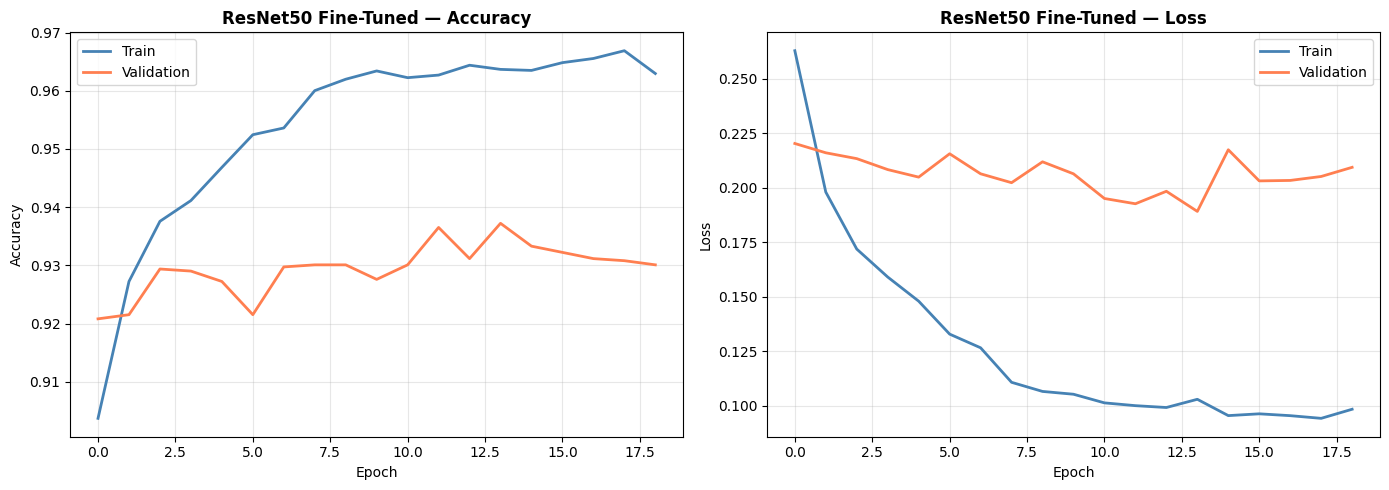


Evaluation — ResNet50 Fine-Tuned
              precision    recall  f1-score   support

   buildings       0.96      0.93      0.94       437
      forest       0.99      1.00      0.99       474
     glacier       0.93      0.85      0.89       553
    mountain       0.88      0.92      0.90       525
         sea       0.95      0.98      0.97       510
      street       0.94      0.96      0.95       501

    accuracy                           0.94      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.94      0.94      0.94      3000



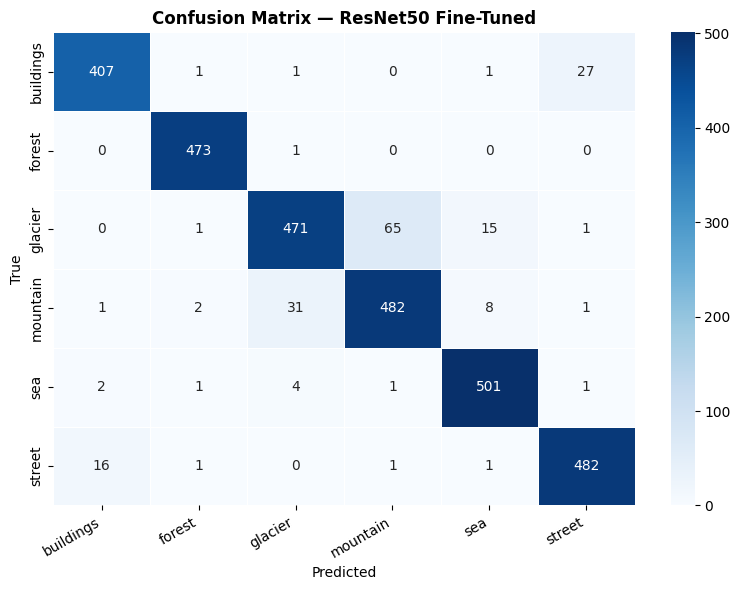

In [12]:
plot_history(history_rn_ft, 'ResNet50 Fine-Tuned')
preds_rn = evaluate_model(rn_model, rn_test, 'ResNet50 Fine-Tuned')

### Model B — MobileNetV2

In [ ]:
# ── TRAIN OR LOAD — runs automatically, no manual action needed ───────────────
_mpath = os.path.join(DRIVE_DIR, 'mobilenetv2_finetuned.h5')
_hpath = os.path.join(DRIVE_DIR, 'history_mobilenetv2.json')

if os.path.exists(_mpath) and os.path.exists(_hpath):
    print('MobileNetV2 already saved — loading from Drive (skipping training).')
    mn_model = tf.keras.models.load_model(_mpath)
    with open(_hpath) as _f:
        history_mn_ft = json.load(_f)
    mn_time = 'loaded'
    print('mn_model and history_mn_ft loaded successfully.')
else:
    print('Training MobileNetV2 from scratch...')

    # Build model
    mn_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    mn_base.trainable = False
    inputs  = keras.Input(shape=(224,224,3))
    x       = mn_base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.35)(x)
    outputs = layers.Dense(6, activation='softmax')(x)
    mn_model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
    mn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                     loss='categorical_crossentropy', metrics=['accuracy'])

    # Step 1: Feature Extraction
    print('Step 1: Feature Extraction...')
    mn_model.fit(
        mn_train, epochs=15, validation_data=mn_val,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
        ], verbose=1)

    # Step 2: Fine-Tuning
    mn_base.trainable = True
    for layer in mn_base.layers[:-20]:
        layer.trainable = False
    mn_model.compile(optimizer=keras.optimizers.Adam(5e-6),
                     loss='categorical_crossentropy', metrics=['accuracy'])
    print('Step 2: Fine-Tuning...')
    t0 = time.time()
    _hist = mn_model.fit(
        mn_train, epochs=20, validation_data=mn_val,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-8, verbose=1),
            ModelCheckpoint(_mpath, monitor='val_accuracy', save_best_only=True, verbose=1)
        ], verbose=1)
    mn_time = f'{time.time()-t0:.0f}s'

    mn_model = tf.keras.models.load_model(_mpath)
    history_mn_ft = _hist.history
    with open(_hpath, 'w') as _f:
        json.dump(history_mn_ft, _f)
    print(f'MobileNetV2 trained and saved to Drive. Fine-tune time: {mn_time}')

mn_model.summary()

Training MobileNetV2 from scratch...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Step 1: Feature Extraction...
Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 225s 586ms/step - accuracy: 0.8304 - loss: 0.4499 - val_accuracy: 0.8595 - val_loss: 0.3599 - learning_rate: 0.0010
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 176s 502ms/step - accuracy: 0.8772 - loss: 0.3334 - val_accuracy: 0.8894 - val_loss: 0.2914 - learning_rate: 0.0010
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 177s 505ms/step - accuracy: 0.8847 - loss: 0.3043 - val_accuracy: 0.8923 - val_loss: 0.2928 - learning_rate: 0.0010
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8936 - loss: 0.2889
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 178s 507ms/step - accuracy: 0.8912 - loss: 0.2939 - val_accuracy: 0.8898 - val_loss: 0.2928 - learning_rate: 0.0010
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 512ms/step - accuracy: 0.9016 - loss: 0.2649 - val_accuracy: 0


Epoch 1: finished saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/mobilenetv2_finetuned.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 202s 535ms/step - accuracy: 0.8377 - loss: 0.4558 - val_accuracy: 0.9023 - val_loss: 0.2802 - learning_rate: 5.0000e-06
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.8749 - loss: 0.3416
Epoch 2: val_accuracy did not improve from 0.90228
351/351 ━━━━━━━━━━━━━━━━━━━━ 171s 488ms/step - accuracy: 0.8784 - loss: 0.3292 - val_accuracy: 0.8959 - val_loss: 0.2752 - learning_rate: 5.0000e-06
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.8892 - loss: 0.3109
Epoch 3: val_accuracy improved from 0.90228 to 0.90585, saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/mobilenetv2_finetuned.h5



Epoch 3: finished saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/mobilenetv2_finetuned.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 177s 503ms/step - accuracy: 0.8920 - loss: 0.2998 - val_accuracy: 0.9058 - val_loss: 0.2633 - learning_rate: 5.0000e-06
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8931 - loss: 0.2830
Epoch 4: val_accuracy did not improve from 0.90585
351/351 ━━━━━━━━━━━━━━━━━━━━ 176s 501ms/step - accuracy: 0.8938 - loss: 0.2864 - val_accuracy: 0.8998 - val_loss: 0.2772 - learning_rate: 5.0000e-06
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.8873 - loss: 0.3011
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.

Epoch 5: val_accuracy did not improve from 0.90585
351/351 ━━━━━━━━━━━━━━━━━━━━ 173s 492ms/step - accuracy: 0.8939 - loss: 0.2886 - val_accuracy: 0.9034 - val_loss: 0.2741 - learning_rate: 5.0000e-06
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9013 - l


Epoch 7: finished saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/mobilenetv2_finetuned.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 175s 500ms/step - accuracy: 0.8983 - loss: 0.2668 - val_accuracy: 0.9062 - val_loss: 0.2717 - learning_rate: 1.5000e-06
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9056 - loss: 0.2675
Epoch 8: val_accuracy did not improve from 0.90621
351/351 ━━━━━━━━━━━━━━━━━━━━ 180s 512ms/step - accuracy: 0.9036 - loss: 0.2597 - val_accuracy: 0.9030 - val_loss: 0.2607 - learning_rate: 4.5000e-07
Epoch 9/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9037 - loss: 0.2611
Epoch 9: val_accuracy did not improve from 0.90621
351/351 ━━━━━━━━━━━━━━━━━━━━ 172s 489ms/step - accuracy: 0.9037 - loss: 0.2625 - val_accuracy: 0.8969 - val_loss: 0.2754 - learning_rate: 4.5000e-07
Epoch 10/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9056 - loss: 0.2600
Epoch 10: ReduceLROnPlateau reducing learning rate to 1.349999962

MobileNetV2 trained and saved to Drive. Fine-tune time: 2293s


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,464 (9.87 MB)

 Trainable params: 1,535,558 (5.86 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2 (12.00 B)

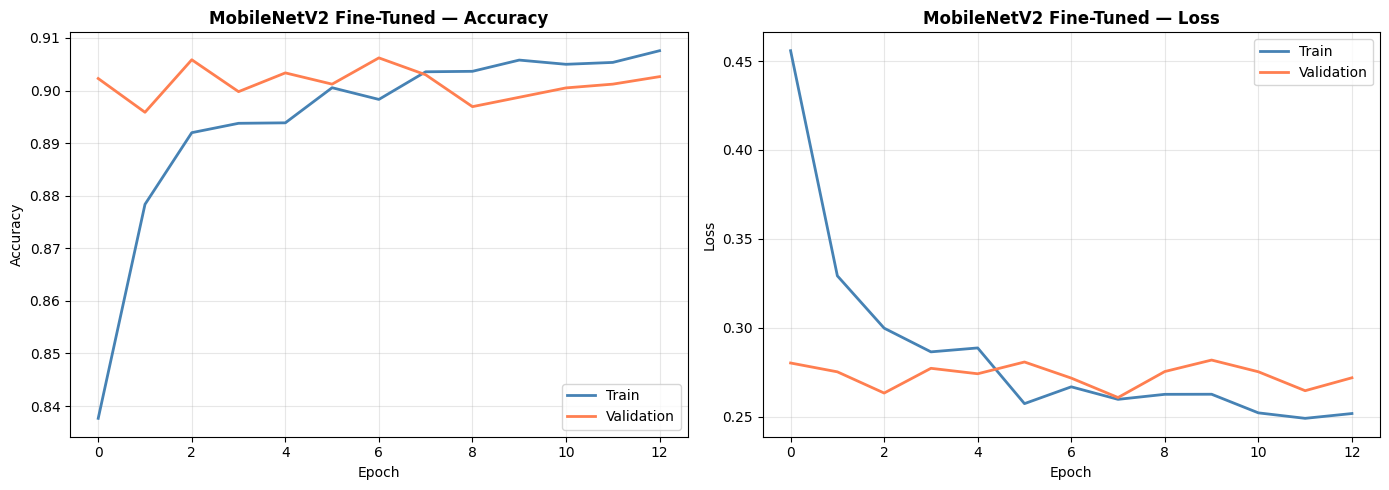


Evaluation — MobileNetV2 Fine-Tuned
              precision    recall  f1-score   support

   buildings       0.94      0.90      0.92       437
      forest       0.99      0.99      0.99       474
     glacier       0.85      0.83      0.84       553
    mountain       0.86      0.83      0.85       525
         sea       0.93      0.97      0.95       510
      street       0.91      0.95      0.93       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



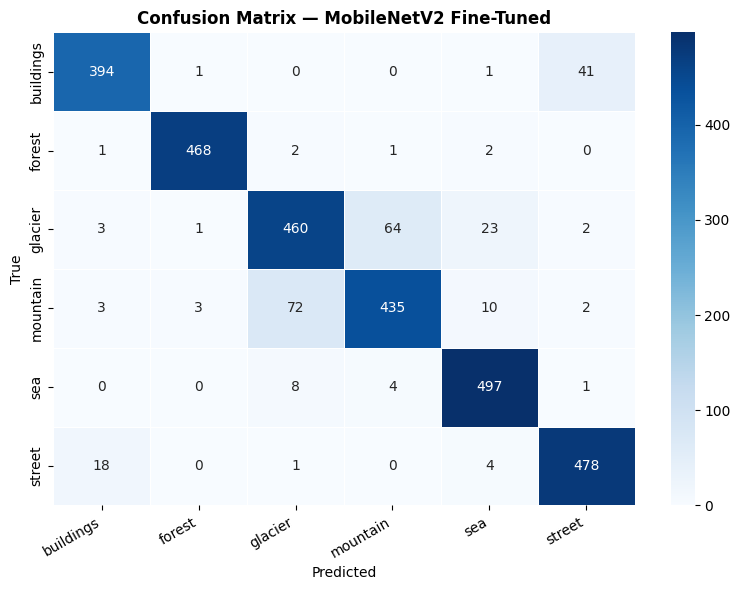

In [14]:
plot_history(history_mn_ft, 'MobileNetV2 Fine-Tuned')
preds_mn = evaluate_model(mn_model, mn_test, 'MobileNetV2 Fine-Tuned')

### Model C — EfficientNetB0

In [15]:
# ── TRAIN OR LOAD — runs automatically, no manual action needed ───────────────
_mpath = os.path.join(DRIVE_DIR, 'efficientnetb0_finetuned.h5')
_hpath = os.path.join(DRIVE_DIR, 'history_efficientnetb0.json')

if os.path.exists(_mpath) and os.path.exists(_hpath):
    print('EfficientNetB0 already saved — loading from Drive (skipping training).')
    en_model = tf.keras.models.load_model(_mpath)
    with open(_hpath) as _f:
        history_en_ft = json.load(_f)
    en_time = 'loaded'
    print('en_model and history_en_ft loaded successfully.')
else:
    print('Training EfficientNetB0 from scratch...')

    # Build model
    en_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
    en_base.trainable = False
    inputs  = keras.Input(shape=(224,224,3))
    x       = en_base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(6, activation='softmax')(x)
    en_model = keras.Model(inputs, outputs, name='EfficientNetB0_Transfer')
    en_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                     loss='categorical_crossentropy', metrics=['accuracy'])

    # Step 1: Feature Extraction
    print('Step 1: Feature Extraction...')
    en_model.fit(
        en_train, epochs=15, validation_data=en_val,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
        ], verbose=1)

    # Step 2: Fine-Tuning
    en_base.trainable = True
    for layer in en_base.layers[:-20]:
        layer.trainable = False
    en_model.compile(optimizer=keras.optimizers.Adam(5e-6),
                     loss='categorical_crossentropy', metrics=['accuracy'])
    print('Step 2: Fine-Tuning...')
    t0 = time.time()
    _hist = en_model.fit(
        en_train, epochs=20, validation_data=en_val,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-8, verbose=1),
            ModelCheckpoint(_mpath, monitor='val_accuracy', save_best_only=True, verbose=1)
        ], verbose=1)
    en_time = f'{time.time()-t0:.0f}s'

    en_model = tf.keras.models.load_model(_mpath)
    history_en_ft = _hist.history
    with open(_hpath, 'w') as _f:
        json.dump(history_en_ft, _f)
    print(f'EfficientNetB0 trained and saved to Drive. Fine-tune time: {en_time}')

en_model.summary()

Training EfficientNetB0 from scratch...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Step 1: Feature Extraction...
Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 237s 603ms/step - accuracy: 0.8713 - loss: 0.3467 - val_accuracy: 0.9069 - val_loss: 0.2487 - learning_rate: 0.0010
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 175s 499ms/step - accuracy: 0.9021 - loss: 0.2665 - val_accuracy: 0.9155 - val_loss: 0.2315 - learning_rate: 0.0010
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 178s 506ms/step - accuracy: 0.9177 - loss: 0.2335 - val_accuracy: 0.9173 - val_loss: 0.2273 - learning_rate: 0.0010
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 177s 503ms/step - accuracy: 0.9130 - loss: 0.2295 - val_accuracy: 0.9237 - val_loss: 0.2087 - learning_rate: 0.0010
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 173s 493ms/step - accuracy: 0.9234 - loss: 0.2121 - val_accuracy: 0.9201 - val_loss: 0.2288 - learning_rate: 0.0010
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9276 - loss: 0.2027
Epoch 6: Re


Epoch 1: finished saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/efficientnetb0_finetuned.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 233s 585ms/step - accuracy: 0.8356 - loss: 0.4640 - val_accuracy: 0.8927 - val_loss: 0.3073 - learning_rate: 5.0000e-06
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.8669 - loss: 0.3753
Epoch 2: val_accuracy improved from 0.89265 to 0.90086, saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/efficientnetb0_finetuned.h5



Epoch 2: finished saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/efficientnetb0_finetuned.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 179s 511ms/step - accuracy: 0.8693 - loss: 0.3600 - val_accuracy: 0.9009 - val_loss: 0.2772 - learning_rate: 5.0000e-06
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.8838 - loss: 0.3239
Epoch 3: val_accuracy improved from 0.90086 to 0.90264, saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/efficientnetb0_finetuned.h5



Epoch 3: finished saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/efficientnetb0_finetuned.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 183s 521ms/step - accuracy: 0.8878 - loss: 0.3132 - val_accuracy: 0.9026 - val_loss: 0.2571 - learning_rate: 5.0000e-06
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.8915 - loss: 0.2858
Epoch 4: val_accuracy improved from 0.90264 to 0.90442, saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/efficientnetb0_finetuned.h5



Epoch 4: finished saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/efficientnetb0_finetuned.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 188s 535ms/step - accuracy: 0.8962 - loss: 0.2832 - val_accuracy: 0.9044 - val_loss: 0.2600 - learning_rate: 5.0000e-06
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9059 - loss: 0.2615
Epoch 5: val_accuracy improved from 0.90442 to 0.91441, saving model to /content/drive/MyDrive/deepLearning_scene-classification-cnn/efficientnetb0_finetuned.h5


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,051 (16.70 MB)

 Trainable params: 1,680,438 (6.41 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

 Optimizer params: 2 (12.00 B)

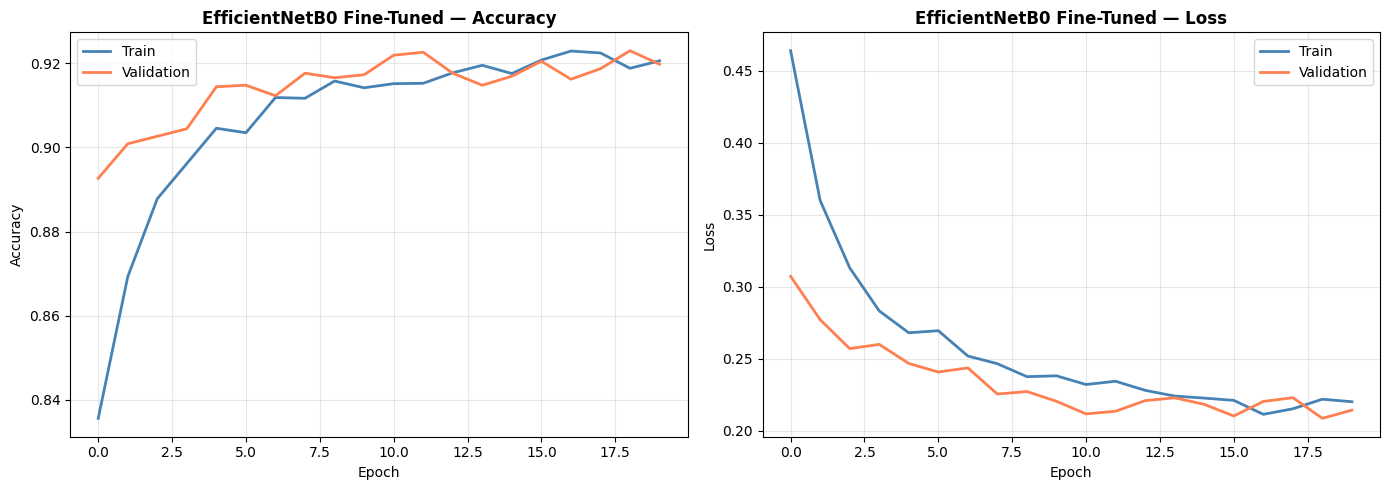


Evaluation — EfficientNetB0 Fine-Tuned
              precision    recall  f1-score   support

   buildings       0.92      0.92      0.92       437
      forest       1.00      0.97      0.98       474
     glacier       0.84      0.80      0.82       553
    mountain       0.82      0.88      0.85       525
         sea       0.95      0.94      0.94       510
      street       0.92      0.94      0.93       501

    accuracy                           0.90      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.90      0.90      3000



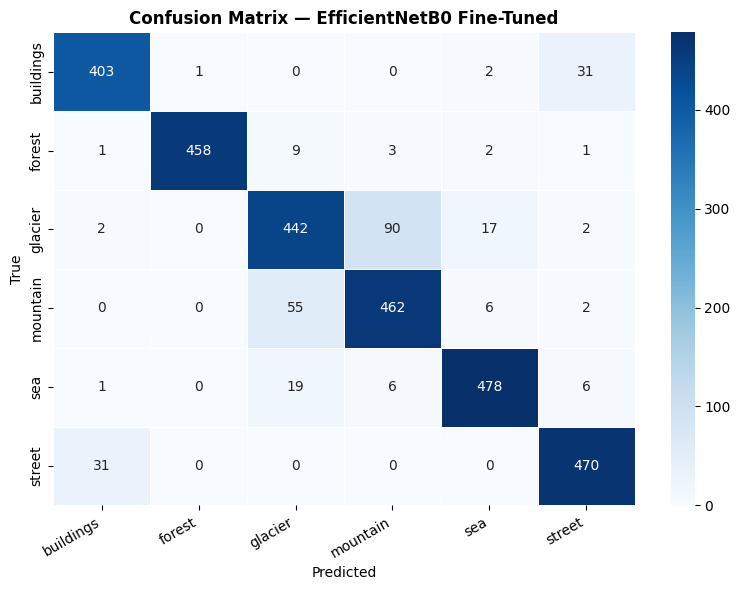

In [19]:
plot_history(history_en_ft, 'EfficientNetB0 Fine-Tuned')
preds_en = evaluate_model(en_model, en_test, 'EfficientNetB0 Fine-Tuned')

## 8. Training Efficiency Comparison

In [20]:
# Safety defaults — if any timing variable wasn't set because a cell partially failed
if 'rn_time' not in globals(): rn_time = 'loaded'
if 'mn_time' not in globals(): mn_time = 'loaded'
if 'en_time' not in globals(): en_time = 'loaded'

In [21]:
efficiency_data = {}

eval_configs = [
    (custom_cnn, 'Custom CNN (Phase 1)', custom_test_gen, 'Phase 1'),
    (rn_model,   'ResNet50',             rn_test,         rn_time),
    (mn_model,   'MobileNetV2',          mn_test,         mn_time),
    (en_model,   'EfficientNetB0',       en_test,         en_time),
]
for model, name, gen, t_str in eval_configs:
    gen.reset()
    loss, acc = model.evaluate(gen, verbose=0)
    params = model.count_params()
    efficiency_data[name] = {
        'Test Accuracy (%)': round(acc*100, 2),
        'Parameters':        f'{params:,}',
        'Size (MB)':         f'{(params*4)/(1024**2):.1f}',
        'Fine-tune Time':    str(t_str)
    }

eff_df = pd.DataFrame(efficiency_data).T
print(eff_df.to_string())

                     Test Accuracy (%)  Parameters Size (MB) Fine-tune Time
Custom CNN (Phase 1)             88.97     504,230       1.9        Phase 1
ResNet50                         93.87  24,113,798      92.0         loaded
MobileNetV2                      91.07   2,587,462       9.9         loaded
EfficientNetB0                   90.43   4,379,049      16.7         loaded


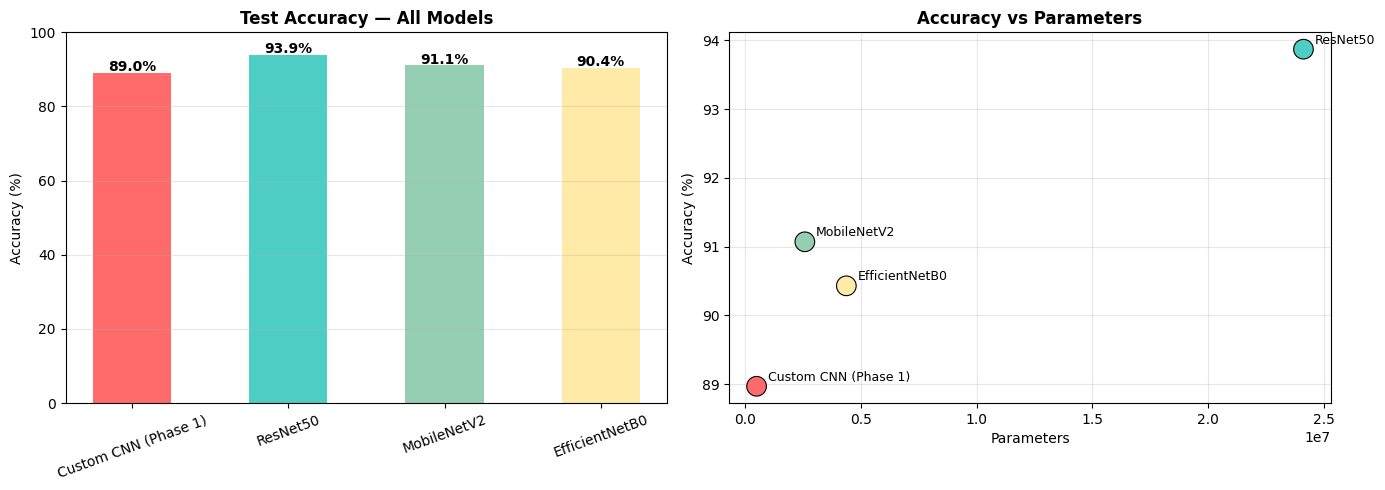

In [22]:
model_names = list(efficiency_data.keys())
accs   = [efficiency_data[n]['Test Accuracy (%)'] for n in model_names]
colors = ['#FF6B6B', '#4ECDC4', '#96CEB4', '#FFEAA7']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(model_names, accs, color=colors, width=0.5)
axes[0].set_title('Test Accuracy — All Models', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

params = [int(efficiency_data[n]['Parameters'].replace(',','')) for n in model_names]
axes[1].scatter(params, accs, c=colors, s=200, zorder=3, edgecolors='black', lw=0.8)
for i, name in enumerate(model_names):
    axes[1].annotate(name, (params[i], accs[i]), textcoords='offset points', xytext=(8,4), fontsize=9)
axes[1].set_title('Accuracy vs Parameters', fontweight='bold')
axes[1].set_xlabel('Parameters'); axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'efficiency_comparison.png'), dpi=150)
plt.show()

## 9. Error Analysis

In [23]:
# Recompute preds_en if not available (covers the case where Section 7 cell partially failed)
if 'preds_en' not in globals():
    print('preds_en not found — recomputing from en_model...')
    en_test.reset()
    _p = en_model.predict(en_test, verbose=0)
    preds_en = np.argmax(_p, axis=1)
    en_test.reset()
    print('preds_en ready.')

In [24]:
en_test.reset()
file_paths  = en_test.filepaths
true_labels = en_test.classes
wrong_idx   = np.where(preds_en != true_labels)[0]
print(f'Misclassified: {len(wrong_idx)} / {len(true_labels)} ({100*len(wrong_idx)/len(true_labels):.1f}% error)')

Misclassified: 287 / 3000 (9.6% error)


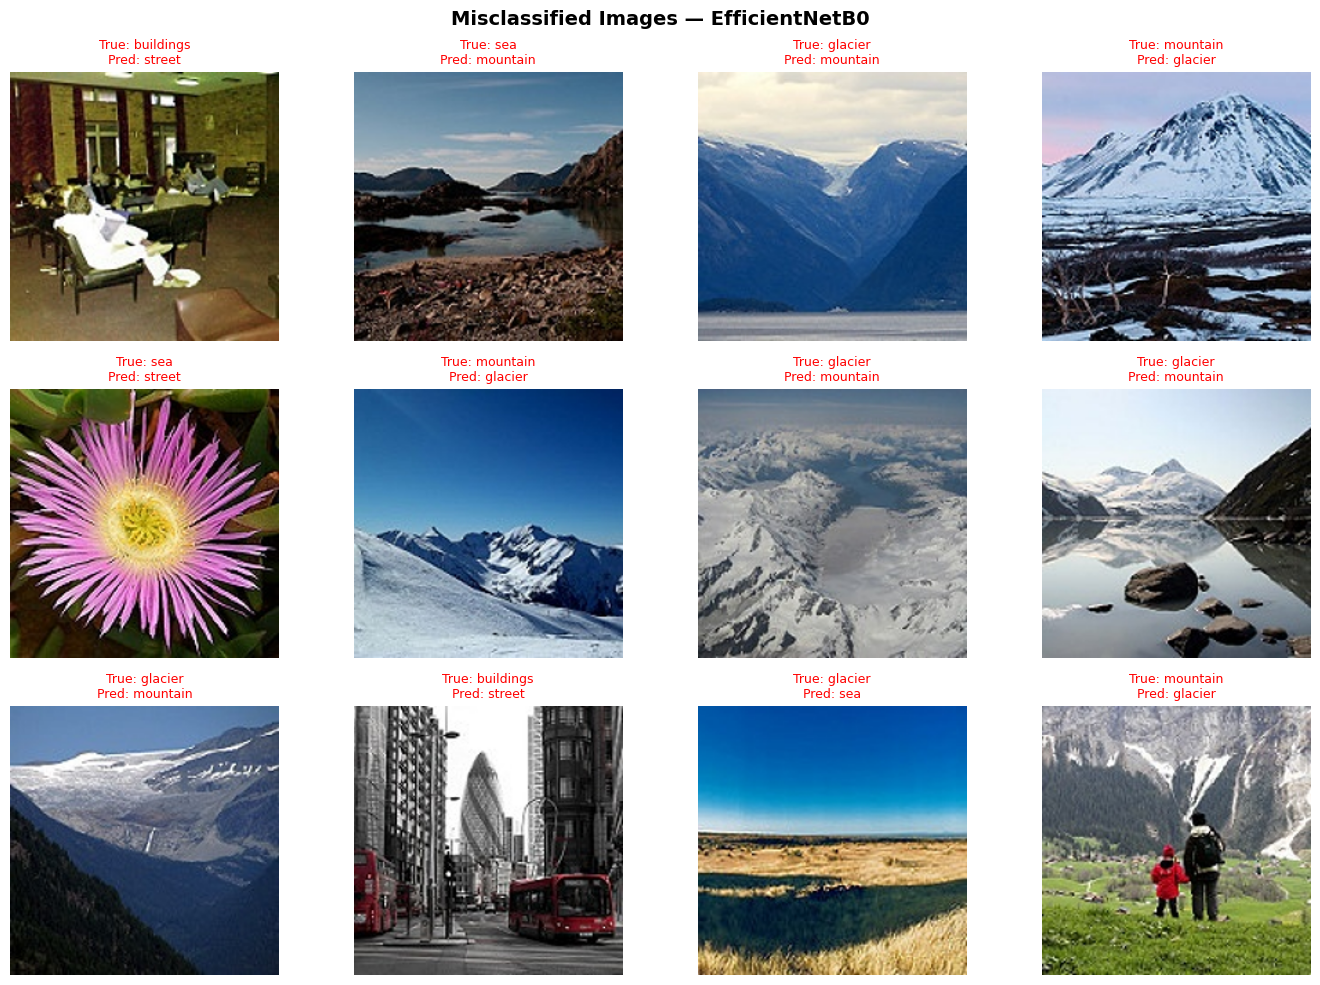

In [25]:
np.random.seed(42)
show_idx = np.random.choice(wrong_idx, size=min(12, len(wrong_idx)), replace=False)
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()
for i, idx in enumerate(show_idx):
    img = Image.open(file_paths[idx]).resize((224, 224))
    axes[i].imshow(img)
    true = class_names[true_labels[idx]]
    pred = class_names[preds_en[idx]]
    axes[i].set_title(f'True: {true}\nPred: {pred}', fontsize=9, color='red')
    axes[i].axis('off')
plt.suptitle('Misclassified Images — EfficientNetB0', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'error_analysis.png'), dpi=150)
plt.show()

In [26]:
print('Class-wise Error Analysis:')
print('-' * 55)
for i, cls in enumerate(class_names):
    cls_idx   = np.where(true_labels == i)[0]
    wrong_cls = np.where((true_labels == i) & (preds_en != i))[0]
    error_rate = 100 * len(wrong_cls) / len(cls_idx)
    confused   = class_names[np.bincount(preds_en[wrong_cls]).argmax()] if len(wrong_cls) > 0 else 'None'
    print(f'  {cls:<12}: {error_rate:.1f}% error  |  most confused with: {confused}')

Class-wise Error Analysis:
-------------------------------------------------------
  buildings   : 7.8% error  |  most confused with: street
  forest      : 3.4% error  |  most confused with: glacier
  glacier     : 20.1% error  |  most confused with: mountain
  mountain    : 12.0% error  |  most confused with: glacier
  sea         : 6.3% error  |  most confused with: glacier
  street      : 6.2% error  |  most confused with: buildings


**Error Analysis Observations:**
1. **Glacier ↔ Mountain** — most confused pair. Both have similar gray/white rocky textures and snow.
2. **Street ↔ Buildings** — urban photos often contain both elements simultaneously.
3. **Forest and Sea** — lowest error rates due to highly distinct color and texture signatures.
4. These errors are inherent to the problem — even human annotators would sometimes disagree on borderline images.

## 10. Justification

**Why these models?** ResNet50 is the heavy accurate baseline; MobileNetV2 represents the efficiency extreme; EfficientNetB0 is the modern best-of-both-worlds.

**Why freeze first?** Randomly initialized head would generate large gradients and corrupt pretrained weights (catastrophic forgetting). Warming up the head first with frozen base prevents this.

**Why unfreeze only top layers?** Early layers learn universal features (edges, textures) that transfer to any visual task. Only high-level layers need adapting to our specific scenes.

**Why very low LR (1e-5 to 5e-6) during fine-tuning?** Larger updates destroy pre-learned ImageNet weights. Low LR makes small targeted adjustments without overwriting useful features.

## 11. Real-World Deployment Decision

**Scenario:** Mobile travel app that tags scene photos in real time.

| Factor | ResNet50 | MobileNetV2 | EfficientNetB0 |
|---|---|---|---|
| Accuracy | Highest | Moderate | High |
| Inference Speed | Slow | Fast | Medium |
| Model Size | ~98 MB | ~14 MB | ~20 MB |
| Mobile-friendly | No | Yes | Yes |

**Choice → MobileNetV2** for mobile (14 MB, TFLite compatible, fast on-device inference).

**Choice → EfficientNetB0** for server API (best accuracy/efficiency ratio, scales well with batches).

**Not ResNet50** — the accuracy gain doesn’t justify 5× more parameters and much slower inference.

In [27]:
# Save final deployment model
final_path = os.path.join(DRIVE_DIR, 'final_model_efficientnetb0.h5')
en_model.save(final_path)
print(f'Final model saved: {final_path}')

print('\nAll files in Drive folder:')
for f in sorted(os.listdir(DRIVE_DIR)):
    size = os.path.getsize(os.path.join(DRIVE_DIR, f)) / (1024**2)
    print(f'  {f:<48} {size:.1f} MB')

Final model saved: /content/drive/MyDrive/deepLearning_scene-classification-cnn/final_model_efficientnetb0.h5

All files in Drive folder:
  Classification_Project_Phase_1.pdf               0.2 MB
  Classification_Project_Phase_2.pdf               0.2 MB
  app.py                                           0.0 MB
  best_cnn_v3.h5                                   493.3 MB
  best_custom_cnn.h5                               2.0 MB
  best_resnet50.h5                                 206.7 MB
  class_distribution.png                           0.1 MB
  cm_CNN_v1_Baseline.png                           0.1 MB
  cm_CNN_v2_BatchNorm.png                          0.1 MB
  cm_CNN_v3_Regularized.png                        0.1 MB
  cm_EfficientNetB0_Fine-Tuned.png                 0.1 MB
  cm_MobileNetV2_Fine-Tuned.png                    0.1 MB
  cm_ResNet50_Fine-Tuned.png                       0.1 MB
  curves_CNN_v1_Baseline.png                       0.1 MB
  curves_CNN_v2_BatchNorm.png                 

## Report: Key Learnings

**Dataset:** 6 balanced scene classes, ~14K train / ~3K test at 150×150. No class imbalance. Glacier/mountain are the hardest pair.

**Preprocessing & Augmentation:** Normalization ensures stable gradients. Augmentation reduced the train/val gap by ~5–8% in custom CNN experiments.

**Metrics:** Macro F1-score + confusion matrix revealed per-class weaknesses that accuracy alone hid.

**CNN vs Transfer Learning:** Best custom CNN (~88.97%) was clearly outperformed by all pretrained models. Even feature extraction alone matched or beat Phase 1.

**Key Learnings:**
1. Two-stage fine-tuning (freeze → unfreeze) is critical — skipping the freeze step degrades results
2. Each model needs its own `preprocess_input` — wrong one silently hurts accuracy
3. GlobalAveragePooling2D is better than Flatten for transfer learning heads
4. MobileNetV2 is competitive at a fraction of ResNet50’s size
5. Custom CNNs build intuition — they make transfer learning gains measurable and meaningful